In [6]:
import jax
import jax.numpy as jnp

import numpy
from matplotlib import pyplot as plt

from learned_optimization.outer_trainers import full_es
from learned_optimization.outer_trainers import truncated_pes
from learned_optimization.outer_trainers import gradient_learner
from learned_optimization.outer_trainers import truncation_schedule

from learned_optimization.tasks import quadratics
from learned_optimization.tasks.fixed import image_mlp
from learned_optimization.tasks import base as tasks_base
from learned_optimization.tasks.datasets import base as datasets_base

from learned_optimization.learned_optimizers import base as lopt_base
from learned_optimization.learned_optimizers import mlp_lopt
from learned_optimization.optimizers import base as opt_base

from learned_optimization import optimizers
from learned_optimization import eval_training

import haiku as hk
import tqdm

In [9]:
key = jax.random.PRNGKey(0)
task = image_mlp.ImageMLP_FashionMnist8_Relu32()

params = task.init(key)
print(jax.tree_util.tree_structure(params))
print(jax.tree_util.tree_map(lambda x: x.shape, params))

PyTreeDef({'mlp/~/linear_0': {'b': *, 'w': *}, 'mlp/~/linear_1': {'b': *, 'w': *}})
{'mlp/~/linear_0': {'b': (32,), 'w': (64, 32)}, 'mlp/~/linear_1': {'b': (10,), 'w': (32, 10)}}


In [11]:
batch = next(task.datasets.train)
jax.tree_util.tree_map( lambda x: (x.shape, x.dtype), batch)

FlatMap({
  'image': ((128, 8, 8, 1), dtype('float32')),
  'label': ((128,), dtype('int32')),
})

In [12]:
key, key1 = jax.random.split(key)

loss = task.loss(params, key1, batch)
loss

Array(2.3176446, dtype=float32)

In [15]:
loss, grad = jax.value_and_grad(task.loss)(params, key1, batch)
jax.tree_util.tree_map(lambda x: x.shape, grad)

{'mlp/~/linear_0': {'b': (32,), 'w': (64, 32)},
 'mlp/~/linear_1': {'b': (10,), 'w': (32, 10)}}

In [24]:
grad_fn = jax.jit(jax.value_and_grad(task.loss))
key = jax.random.PRNGKey(0)
params = task.init(key)
lr = 0.1

for i in range(1000):
    key, key1 = jax.random.split(key)
    batch = next(task.datasets.train)
    l, grads = grad_fn(params, key1, batch)
    params = jax.tree_util.tree_map(lambda p, g: p - lr*g, params, grads)
    if i%100 == 0:
        test_l = task.loss(params, key, next(task.datasets.test))
        print(f"train loss at {i}: {float(l)}. Test loss: {float(test_l)}")

train loss at 0: 2.2845046520233154. Test loss: 2.320131301879883
train loss at 100: 1.3356246948242188. Test loss: 1.3875573873519897
train loss at 200: 1.0104143619537354. Test loss: 1.0793914794921875
train loss at 300: 0.8467453122138977. Test loss: 0.9300081729888916
train loss at 400: 0.8599814176559448. Test loss: 0.764909029006958
train loss at 500: 0.824335515499115. Test loss: 0.7294652462005615
train loss at 600: 0.8042398691177368. Test loss: 0.7608433961868286
train loss at 700: 0.7359169721603394. Test loss: 0.7270013093948364
train loss at 800: 0.6631714105606079. Test loss: 0.5303723812103271
train loss at 900: 0.7689268589019775. Test loss: 0.7120078802108765


In [25]:
fake_params = {"a": jnp.zeros((2,))}

opt = opt_base.SGD(1e-4)
opt_state = opt.init(fake_params)
opt_state

OptaxState(params={'a': Array([0., 0.], dtype=float32)}, state=None, optax_opt_state=(EmptyState(), EmptyState()), iteration=0)

In [26]:
fake_grads = {"a": jnp.ones((2,))}
fake_loss = 10.

next_opt_state = opt.update(opt_state, fake_grads, fake_loss)
opt.get_params(next_opt_state)

{'a': Array([-0.0001, -0.0001], dtype=float32)}

In [38]:
task = image_mlp.ImageMLP_FashionMnist8_Relu32()
key = jax.random.PRNGKey(0)
params = task.init(key)
# print(params)
opt = opt_base.Adam(1e-2)
opt_state = opt.init(params, key)
# print(opt_state)
for i in range(10):
    batch = next(task.datasets.train)
    # print(batch)
    key, key1 = jax.random.split(key)
    params = opt.get_params(opt_state)
    loss, grads = jax.value_and_grad(task.loss)(params, key1, batch)
    opt_state = opt.update(opt_state, grads, loss)
    print(loss)

2.3364477
2.2367635
2.1612422
2.1102824
2.0390062
1.9848582
1.8971167
1.8681295
1.7350136
1.7056153


In [ ]:
task = image_mlp.ImageMLP_FashionMnist8_Relu32()
key = jax.random.PRNGKey(0)
params = task.init(key)

opt = opt_base.Adam(1e-2)
opt_state = opt.init(params)

@jax.jit
def update(opt_state, key, batch):
    key, key1 = jax.random.split(key)
    bb = next(task.datasets.train)
    params, model_state = opt.get_params_state(opt_state)
    print(model_state)
    loss, grads = jax.value_and_grad(task.loss)(params, key, batch)
    print(opt_state)
    opt_state = opt.update(opt_state, grads, loss=loss)
    print(opt_state)
    return opt_state, key, loss

for i in range(10):
    batch = next(task.datasets.train)
    opt_state, key, loss = update(opt_state, key, batch)
    print(loss)

FlatMap({
  'image': JitTracer<float32[128,8,8,1]>,
  'label': JitTracer<int32[128]>,
})
FlatMap({
  'image': array([[[[0.00000000e+00],
                    [0.00000000e+00],
                    [1.10049017e-01],
                    ...,
                    [7.45098069e-02],
                    [0.00000000e+00],
                    [0.00000000e+00]],
           
                   [[0.00000000e+00],
                    [0.00000000e+00],
                    [6.79411769e-01],
                    ...,
                    [7.93627441e-01],
                    [2.45098054e-04],
                    [0.00000000e+00]],
           
                   [[0.00000000e+00],
                    [4.49264705e-01],
                    [8.00735295e-01],
                    ...,
                    [8.79901946e-01],
                    [3.08823526e-01],
                    [0.00000000e+00]],
           
                   ...,
           
                   [[0.00000000e+00],
                    [6.816176

In [65]:
# Defining custom optimizer

import flax
from typing import Any

@flax.struct.dataclass
class MomentumOptState:
    params: Any
    model_state: Any
    iteration: jnp.ndarray
    momentums: Any

class MomentumOptimizer(opt_base.Optimizer):
    
    def __init__(self, lr=1e-3, momentum=0.9):
        super().__init__()
        self._lr = lr
        self._momentum = momentum
        
    def get_state(self, opt_state):
        return opt_state.model_state
    
    def get_params(self, opt_state):
        return opt_state.params
    
    def init(self, params, model_state=None, **kwargs):
        return MomentumOptState(
            params=params,
            model_state=model_state,
            momentums=jax.tree_util.tree_map(jnp.zeros_like, params),
            iteration=jnp.asarray(0, dtype=jnp.int32)
        )
        

    def update(self, opt_state, grads, model_state):
        def update_fn(momentum, grad, param):
            next_m = momentum * self._momentum + grad * (1 - self._momentum)
            next_p = param - next_m * self._lr
            return next_p, next_m

        # Use tree_map to apply update_fn to each leaf in the tree structure
        x = jax.tree_util.tree_map(
            lambda momentum, grad, param: update_fn(momentum, grad, param),
            opt_state.momentums, grads, opt_state.params
        )
        print(x)
        output_params, output_momentums = x
        print(output_momentums)
        print(output_params)
        # Return the updated opt_state with the new params and momentums
        return MomentumOptState(
            params=output_params,
            model_state=model_state,
            iteration=opt_state.iteration + 1,
            momentums=output_momentums
        )

        
opt = MomentumOptimizer(lr=1)
opt_state = opt.init({"a": 1.0, "b": 2.0})
opt.update(opt_state, {"a": -1.0, "b": 1.0}, 1.0)

{'a': (Array(1.1, dtype=float32, weak_type=True), Array(-0.1, dtype=float32, weak_type=True)), 'b': (Array(1.9, dtype=float32, weak_type=True), Array(0.1, dtype=float32, weak_type=True))}
b
a


MomentumOptState(params='a', model_state=1.0, iteration=Array(1, dtype=int32), momentums='b')

In [45]:
lopt = lopt_base.LearnableAdam()
theta = lopt.init(key)
theta

opt = lopt.opt_fn(theta)
opt_state = opt.init({"p": jnp.zeros([2,])})


In [47]:
task = image_mlp.ImageMLP_FashionMnist8_Relu32()
key = jax.random.PRNGKey(0)

lopt = lopt_base.LearnableAdam()

def meta_loss(theta, key, batch):
    opt = lopt.opt_fn(theta)
    key1, key = jax.random.split(key)
    param = task.init(key1)
    opt_state = opt.init(param)
    for i in range(4):
        param = opt.get_params(opt_state)
        key1, key = jax.random.split(key)
        l, grad = jax.value_and_grad(task.loss)(param, key1, batch)
        opt_state = opt.update(opt_state, grad, l)
    param, state = opt.get_params_state(opt_state)
    key1, key = jax.random.split(key)
    final_loss = task.loss(param, key1, batch)
    return final_loss

batch = next(task.datasets.train)
meta_loss(theta, key, batch)

Array(2.2672672, dtype=float32)

In [48]:
meta_value_and_grad = jax.jit(jax.value_and_grad(meta_loss))

ml, meta_grad = meta_value_and_grad(theta, key, batch)
meta_grad

{'log_epsilon': Array(7.813052e-08, dtype=float32, weak_type=True),
 'log_lr': Array(-0.05490893, dtype=float32, weak_type=True),
 'one_minus_beta1': Array(9.462236e-06, dtype=float32),
 'one_minus_beta2': Array(-3.056526e-07, dtype=float32)}

In [49]:
theta_opt = opt_base.Adam(1e-2)

key = jax.random.PRNGKey(0)
theta = lopt.init(key)
theta_opt_state = theta_opt.init(theta)

learning_rates = []
learnable_adam_meta_losses = []
for i in range(2000):
    batch = next(task.datasets.train)
    key, key1 = jax.random.split(key)
    theta = theta_opt.get_params(theta_opt_state)
    ml, meta_grad = meta_value_and_grad(theta, key, batch)
    theta_opt_state = theta_opt.update(theta_opt_state, meta_grad, ml)
    learning_rates.append(theta["log_lr"])
    learnable_adam_meta_losses.append(ml)
    if i % 100 == 0:
        print(ml)

2.258893
2.1435392
1.6287003
1.124637
1.151026
1.2013901
1.1442099
1.2689922
1.3036683
1.1609715
1.5189989
1.1434304
1.3100195
1.04907
1.1879709
1.2017269
1.1939284
1.2104828
1.108221
1.2565413


Text(0.5, 0, 'meta-iteration')

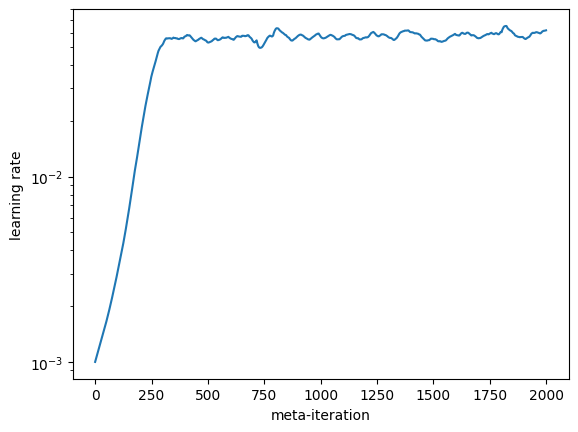

In [51]:
import numpy as np
from matplotlib import pyplot as pyplot

plt.semilogy(np.exp(learning_rates))
plt.ylabel("learning rate")
plt.xlabel("meta-iteration")

9.4921875
9.284325
8.298026
7.678981
7.541124
7.847093
7.8398466
7.496311
7.411434
7.424335
7.4463215
7.4391103
7.8458805
7.406521
7.202177
7.126807
8.033935
7.6832237
7.5607734
7.955021


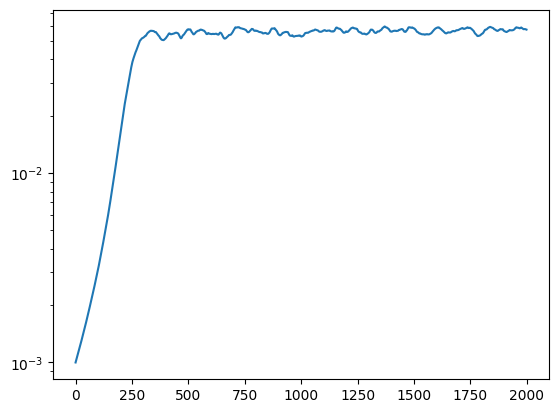

In [ ]:

task = image_mlp.ImageMLP_FashionMnist8_Relu32()
key = jax.random.PRNGKey(0)

lopt = lopt_base.LearnableAdam()

# we want to train this theta using meta_loss, how theta optimizer performs on the task.
def meta_loss_fn(theta, key, batch, meta_loss):
    opt = lopt.opt_fn(theta)
    key, key1 = jax.random.split(key)
    params = task.init(key1)
    opt_state = opt.init(params)
    for i in range(4):
        params = opt.get_params(opt_state)
        key, key1 = jax.random.split(key)
        l, grads = jax.value_and_grad(task.loss)(opt_state.params, key1, batch)
        # l, grads = jax.value_and_grad(task.loss)(params, key1, batch)
        meta_loss += l
        opt_state = opt.update(opt_state, grads, l)
    params, state = opt.get_params_state(opt_state)
    key1, key = jax.random.split(key)
    final_loss = task.loss(params, key1, batch)
    # final_loss = task.loss(opt_state.params, key1, batch)
    return final_loss

theta_opt = opt_base.Adam(1e-2)

key, key1 = jax.random.split(key)
theta = lopt.init(key1)
theta_opt_state = theta_opt.init(theta)

meta_losses = []
learning_rates = []
meta_value_and_grad = jax.jit(jax.value_and_grad(meta_loss_fn))

for i in range(2000):
    batch = next(task.datasets.train)
    key, key1 = jax.random.split(key)
    theta = theta_opt.get_params(theta_opt_state)
    meta_loss = jnp.asarray(0, dtype=jnp.int32)
    ml, meta_grads = meta_value_and_grad(theta, key1, batch, meta_loss)
    ml, meta_grads = meta_value_and_grad(theta_opt_state.params, key1, batch, meta_loss)
    # theta_opt_state = theta_opt.update(theta_opt_state, meta_grads, ml)
    meta_losses.append(ml)
    learning_rates.append(theta["log_lr"])
    if i % 100 == 0:
        print(ml)

# plt.semilogy(meta_losses)
plt.semilogy(np.exp(learning_rates))